# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [3]:

# mostrar las primeras 5 filas de plans
plans.head(5)


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

En el dataset users, la columna city presenta aproximadamente un 11.7% de valores ausentes. Debido a que la ciudad puede ser relevante para futuros análisis de segmentación geográfica y comportamiento de clientes, estos valores no serán eliminados. En su lugar, se reemplazarán por una categoría como "Unknown" o "No registrada" para conservar los registros y evitar pérdida de información.

La columna churn_date contiene alrededor del 88.3% de valores nulos. Sin embargo, estos valores no representan un error de calidad de datos, sino que indican que el cliente continúa activo y no ha cancelado el servicio. Por esta razón, los valores se conservarán como nulos y se documentará su significado.

En el dataset usage, la columna duration contiene aproximadamente un 55% de valores faltantes, mientras que length presenta cerca de un 44%. Tras revisar la estructura de los datos, se observa que estos valores dependen del tipo de actividad registrado en la columna type. Las llamadas (call) utilizan la columna duration, mientras que los mensajes (message) utilizan la columna length. Por lo tanto, estos valores ausentes son esperados y no serán imputados ni eliminados.

Finalmente, la columna date presenta únicamente 50 valores faltantes (~0.1%). Dado que representan una proporción mínima del dataset, se conservarán y, en caso necesario, se excluirán únicamente de análisis que dependan de información temporal.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` veo todo en orden.
- La columna `age` presenta un valor mínimo de -999, lo cual no es válido para una edad.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`veo todo en orden.
- En las columnas duration y length se observan valores mínimos de 0. Estos valores podrían ser válidos dependiendo del tipo de actividad registrada. Por ejemplo, los mensajes no requieren duración y las llamadas no requieren longitud de texto. Por ello, no se consideran necesariamente valores inválido

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].value_counts()

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city` contiene valores "?", los cuales probablemente representan datos faltantes o valores desconocidos
- La columna `plan` no presenta categorías sospechosas ni valores inválidos. Los únicos planes registrados son Basico y Premium.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` contiene únicamente las categorías esperadas (text y call), por lo que no se identifican valores inválidos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  En la edad encontre que existen valores negativos como -999
- ¿Qué acción tomarías?  Podriamos reemplazarlos con un "NA"

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors = 'coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors = 'coerce')

In [18]:

# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se identificaron 40 registros con fechas de registro correspondientes al año 2026, lo cual es inconsistente con el contexto del proyecto, ya que los datos solo deberían existir hasta 2024. Debido a que no existe suficiente información para inferir las fechas correctas, estos valores serán convertidos a NaT para evitar distorsiones en análisis temporales, como antigüedad de clientes o registros por año.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, En el dataset usage, todos los registros corresponden al año 2024. Aunque existen usuarios registrados desde años anteriores en users, esto no necesariamente representa un error, sino que probablemente indica que el historial de actividad disponible está limitado al año 2024..

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?


En users['reg_date']:
sí hay años fuera de rango (2026),
son inconsistentes con el contexto del proyecto,
se convertirán a NaT.
En usage['date']:
no se detectaron años imposibles,
todos los registros pertenecen a 2024,
esto probablemente indica que el historial de actividad está limitado a ese año,
no se requiere acción correctiva.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:

# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
fecha_2026 = users['reg_date'].dt.year == 2026
users.loc[fecha_2026,'reg_date'] = pd.NaT


# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage[usage['duration'].isna()]['type'].value_counts()

text    22076
Name: type, dtype: int64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage[usage['length'].isna()]['type'].value_counts()

call    17896
Name: type, dtype: int64

Queda demostrado que los nulos dependen del tipo, no son faltantes aleatorios, son estructurales

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum', 'is_call': 'sum','duration':'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns = {'is_text': 'cant_mensajes','is_call': 'cant_llamadas', 'duration': 'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg,users,on='user_id')
user_profile.head(5)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,5.524381,4.478120,23.317054,48.124531
std,1154.898108,2.358416,2.144238,18.168095,17.692032
min,10000.000000,0.000000,0.000000,0.000000,18.000000
25%,10999.500000,4.000000,3.000000,11.120000,33.000000
50%,12000.000000,5.000000,4.000000,19.780000,47.000000
75%,12999.500000,7.000000,6.000000,31.415000,63.000000
max,13999.000000,17.000000,15.000000,155.690000,79.000000


In [29]:
# Distribución porcentual del tipo de plan
users['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

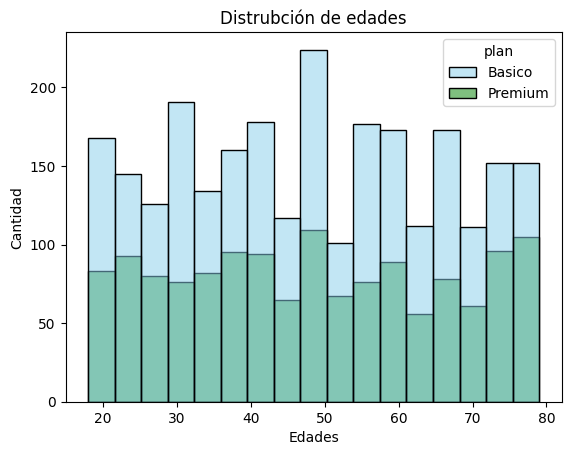

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,x='age',hue='plan',palette=['skyblue','green'])
plt.title('Distrubción de edades')
plt.xlabel('Edades')
plt.ylabel('Cantidad')
plt.show()

💡Insights: 
- La distribución de edades muestra una dispersión relativamente uniforme entre los 18 y 79 años, sin evidencia clara de sesgo hacia edades jóvenes o mayores. No se observan outliers evidentes ni una forma de campana pronunciada. Además, ambos planes presentan distribuciones similares por edad, aunque el plan Básico muestra mayores frecuencias en la mayoría de rangos, posiblemente debido a que representa la mayor proporción de usuarios en el dataset (65%)

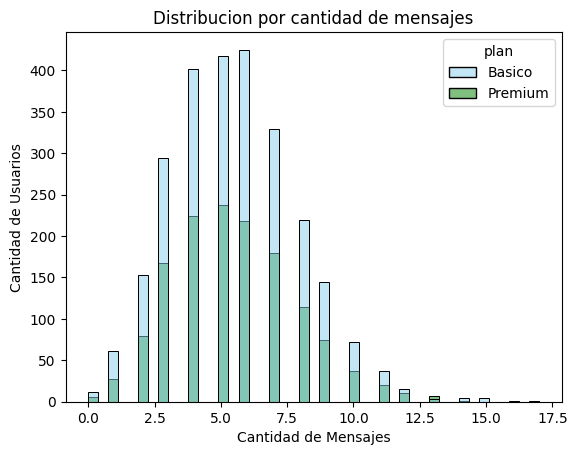

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x= 'cant_mensajes',hue='plan', palette=['skyblue','green'])
plt.title('Distribucion por cantidad de mensajes')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- La distribución de mensajes presenta una asimetría positiva, con mayor concentración entre 3 y 8 mensajes y una cola hacia valores altos. Ambos planes muestran una forma de distribución similar; sin embargo, los usuarios Premium parecen tener mayor presencia en niveles altos de mensajería (10 mensajes o más), lo que podría indicar un patrón de uso más intensivo en este segmento.

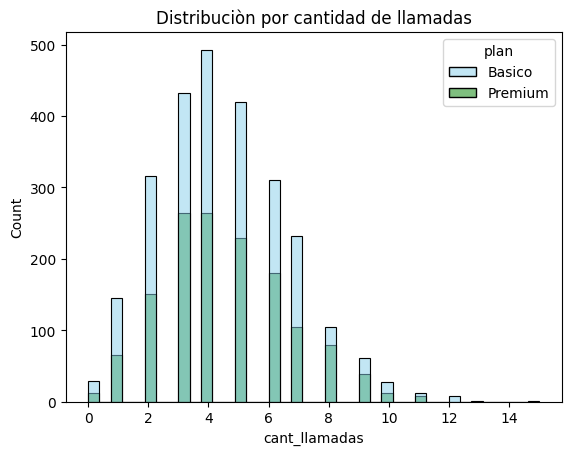

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile,x='cant_llamadas',hue='plan',palette=['skyblue','green'])
plt.title('Distribuciòn por cantidad de llamadas')
plt.show()

💡Insights: 
- La distribución de llamadas presenta asimetría positiva, con mayor concentración entre 3 y 6 llamadas y una cola hacia valores altos. La mayoría de los usuarios realiza pocas llamadas, mientras que los usuarios con actividad muy alta son menos frecuentes. Ambos planes muestran formas de distribución similares, sin diferencias visuales muy marcadas en el comportamiento de llamadas.

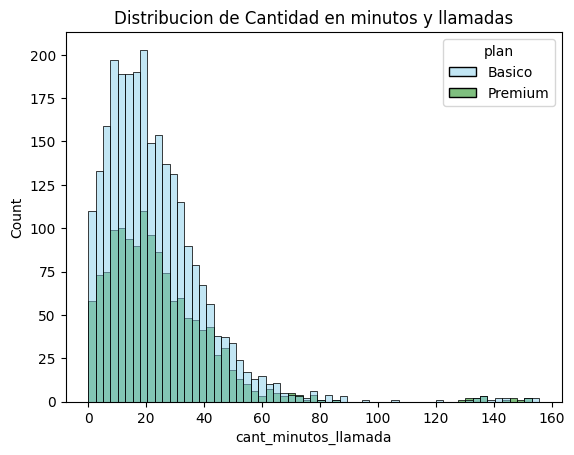

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile,x='cant_minutos_llamada',hue='plan',palette=['skyblue','green'])
plt.title('Distribucion de Cantidad en minutos y llamadas')
plt.show()

💡Insights: 
- La distribución de minutos de llamadas presenta una clara asimetría positiva, con mayor concentración entre aproximadamente 5 y 35 minutos y una cola hacia valores altos. La mayoría de los usuarios consume pocos minutos, mientras que los consumos extremadamente altos son poco frecuentes. En los valores más altos de consumo (superiores a 60 minutos), el plan Premium presenta mayor presencia relativa, lo que podría indicar que los usuarios con uso intensivo prefieren planes con mayores beneficios. En contraste, los consumos bajos y moderados están dominados principalmente por usuarios del plan Básico, que representa la mayor proporción de clientes en el dataset.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

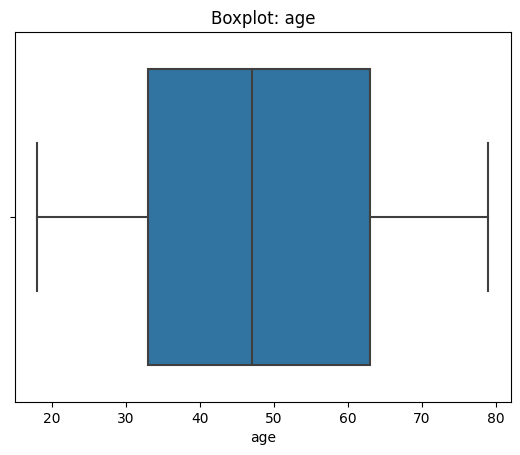

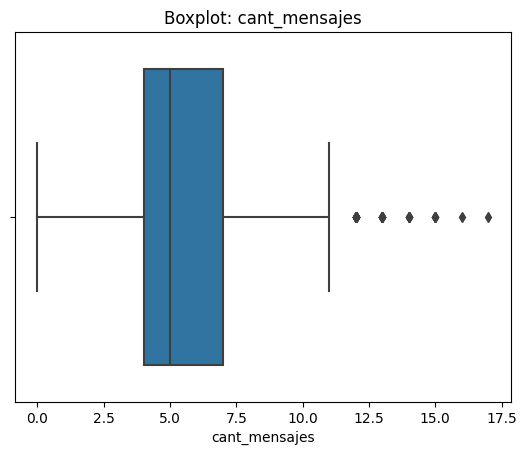

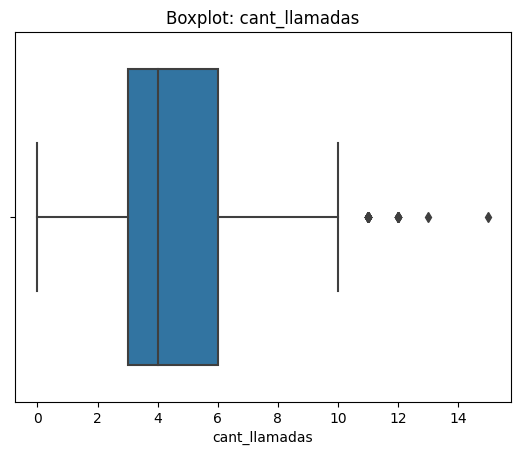

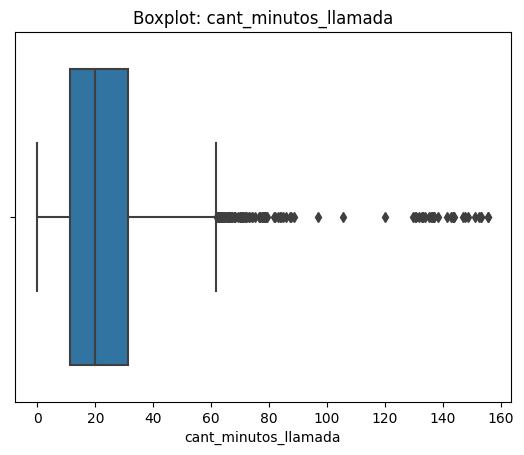

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
La variable age no presenta outliers relevantes tras la limpieza realizada previamente. En cant_mensajes y cant_llamadas se observan algunos valores atípicos superiores; sin embargo, estos parecen razonables dentro del contexto del negocio y podrían representar usuarios con mayor actividad, por lo que se decidió conservarlos.

La variable cant_minutos_llamada presenta una mayor cantidad de outliers hacia valores altos, mostrando una fuerte asimetría positiva. Aun así, los valores no parecen imposibles o inconsistentes, por lo que se mantendrán en el análisis, considerando que podrían corresponder a usuarios intensivos del servicio. Debido a esto, será importante complementar futuros análisis con medidas robustas como la mediana para reducir el impacto de estos valores extremos.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1= user_profile[col].quantile(0.25)
    Q3= user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    superior = Q3 + 1.5*IQR

    print(f'\nColumna: {col}')
    print(f'Límite superior: {superior}')


Columna: cant_mensajes
Límite superior: 11.5

Columna: cant_llamadas
Límite superior: 10.5

Columna: cant_minutos_llamada
Límite superior: 61.8575


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?


Conservaría todos los outliers porque no parecen errores de captura, no hay valores absurdos como 999999. el contexto del negocio sí permite usuarios con mucho consumo.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where((user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),'Bajo uso', np.where((user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),'Uso medio','Alto uso'))

In [38]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(user_profile['age'] < 30, 'Joven', np.where(user_profile['age'] < 60,'Adulto','Adulto Mayor'))

In [40]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

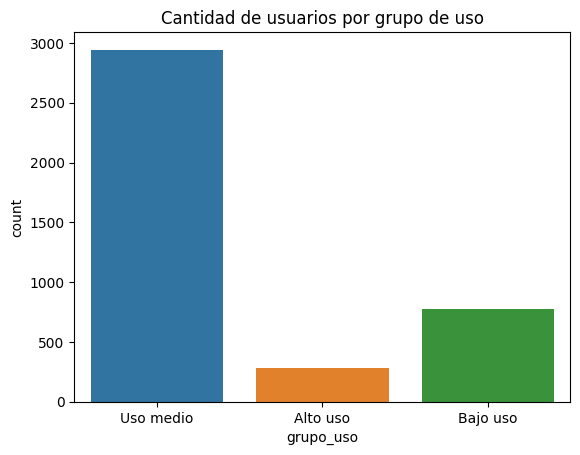

In [41]:

# Visualización de los segmentos por uso
sns.countplot(data=user_profile,x='grupo_uso')
plt.title('Cantidad de usuarios por grupo de uso')
plt.show()


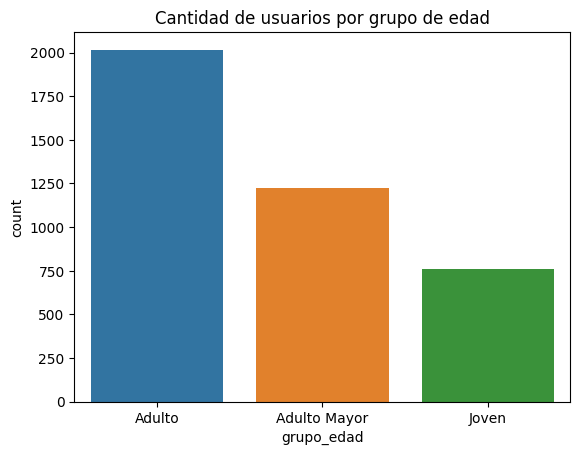

In [42]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile,x='grupo_edad')
plt.title('Cantidad de usuarios por grupo de edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

Durante el proceso de exploración y limpieza de datos se identificaron diversas inconsistencias que podían afectar el análisis. Entre ellas, se encontraron edades negativas representadas con el valor sentinel -999, las cuales fueron reemplazadas por la mediana de la variable para evitar distorsiones estadísticas. También se detectaron registros con el valor "?" en la columna city, mismos que fueron tratados como valores faltantes (NA) debido a su baja proporción dentro del dataset. Además, se identificaron fechas futuras correspondientes al año 2026 en reg_date, fuera del rango temporal esperado del proyecto, por lo que fueron convertidas a NaT.

En la tabla de uso (usage) se encontraron valores nulos en las columnas duration y length; sin embargo, tras analizar la variable type, se concluyó que estos nulos eran coherentes con la lógica del negocio. Por ejemplo, los registros de llamadas no requieren longitud de mensaje, mientras que los mensajes no requieren duración. De igual manera, los valores nulos en churn_date no representaban un error, sino clientes que continúan activos dentro de la compañía.

Respecto a la segmentación de clientes, se identificó que el grupo predominante corresponde a usuarios de “Uso medio”, mientras que los usuarios de “Alto uso” representan una proporción menor. En términos demográficos, el segmento más representativo corresponde a adultos entre 30 y 59 años, mientras que los usuarios jóvenes constituyen la menor proporción del dataset.

Los segmentos más valiosos para ConnectaTel parecen ser los usuarios adultos con un nivel de uso medio y aquellos usuarios intensivos asociados principalmente al plan Premium. Estos segmentos representan una oportunidad comercial importante debido a que muestran un consumo constante de servicios y mayor probabilidad de contratar planes con mayores beneficios o servicios adicionales.

En el análisis de outliers se detectaron valores extremos principalmente en las variables relacionadas con llamadas y mensajes. No obstante, dichos valores se consideran plausibles dentro del contexto de telecomunicaciones y podrían representar usuarios con un consumo intensivo real, por lo que se decidió conservarlos en el análisis. La única excepción correspondió a las edades negativas, las cuales sí fueron tratadas como errores de captura.

Finalmente, se observó que el plan Básico concentra más del 60% de los usuarios, mientras que la mayoría de los clientes pertenece al segmento adulto y presenta un nivel de uso medio. Con base en estos hallazgos, una recomendación para ConnectaTel sería diseñar un plan intermedio entre Básico y Premium, orientado a usuarios con consumo moderado que podrían requerir mayores beneficios sin llegar al costo de un plan Premium. Esto permitiría mejorar la segmentación comercial y aumentar las oportunidades de migración y retención de clientes



⚠️ Problemas detectados en los datos

Se identificaron edades negativas representadas con el valor -999, las cuales fueron reemplazadas por la mediana para evitar distorsiones en el análisis estadístico.
Se encontraron valores "?" en la columna city, mismos que fueron tratados como valores faltantes (NA) debido a su baja proporción.
Se detectaron fechas futuras correspondientes al año 2026 en reg_date, fuera del rango temporal esperado del dataset, por lo que fueron convertidas a NaT.
Los valores nulos en duration y length fueron considerados válidos tras comprobar que dependían de la variable type, ya que llamadas y mensajes requieren información distinta.
Los nulos en churn_date indican clientes activos y no errores de captura.

🔍 Segmentos por Edad

El grupo predominante corresponde a usuarios adultos entre 30 y 59 años.
Los usuarios jóvenes representan el segmento menos frecuente dentro del dataset.
La distribución de edades no mostró outliers relevantes tras el proceso de limpieza.

📊 Segmentos por Nivel de Uso

El segmento de “Uso medio” concentra la mayor parte de los clientes analizados.
Los usuarios de “Alto uso” representan una proporción menor, pero muestran patrones de consumo más intensivos.
El plan Básico concentra más del 60% de los usuarios, mientras que el plan Premium presenta mayor presencia relativa entre usuarios de consumo alto.

➡️ Esto sugiere que el mercado principal de ConnectaTel está compuesto por usuarios adultos con un nivel de uso moderado y preferencia por planes accesibles. Además, existe un grupo más pequeño de usuarios intensivos que podría representar oportunidades de mayor rentabilidad mediante planes con beneficios adicionales.

💡 Recomendaciones

Diseñar un plan intermedio entre Básico y Premium enfocado en usuarios de consumo medio que requieren más beneficios sin llegar al costo de un plan Premium.
Mantener estrategias diferenciadas para usuarios intensivos, ofreciendo paquetes con mayores beneficios en llamadas y mensajes.
Utilizar medidas robustas como la mediana en futuros análisis para reducir el impacto de valores extremos en variables de uso.
Implementar validaciones automáticas en el proceso de captura de datos para evitar edades negativas y fechas fuera de rango.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`